In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── LOAD ─────────────────────────────────────────────────────────────────────
df1 = pd.read_csv("results_1.csv")           # basic prompts
df2 = pd.read_csv("results_2_cleaned.csv")   # improved prompts

# ── CLEAN yes_no ──────────────────────────────────────────────────────────────
def normalize_yn(val):
    return val.strip().lower().rstrip(".,;").strip()

df1["yn"] = df1["yes_no"].apply(normalize_yn)
df2["yn"] = df2["yes_no"].apply(normalize_yn)

# ── CORRECTNESS FLAG ──────────────────────────────────────────────────────────
def is_correct(row):
    if row["subfolder"] == "mitotic":
        return row["yn"] == "yes"
    else:
        return row["yn"] == "no"

df1["correct"] = df1.apply(is_correct, axis=1)
df2["correct"] = df2.apply(is_correct, axis=1)

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
CONDITIONS  = ["raw", "bbox", "mask"]
COND_LABEL  = {"raw": "Raw Crop", "bbox": "Bounding Box", "mask": "Mask"}
COLORS      = {
    "basic":    "#4C72B0",
    "improved": "#C44E52",
    "metrics":  ["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
}

# ── GLOBAL STYLE ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    "figure.dpi":        150,
})

In [22]:
def compute_metrics(df, condition):
    sub  = df[df["folder_type"] == condition]
    y_true = (sub["subfolder"] == "mitotic").astype(int)
    y_pred = (sub["yn"] == "yes").astype(int)
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {"Precision": precision, "Recall": recall, "F1": f1, "Specificity": specificity}

def hn_yes_rate(df, condition):
    """Proportion of hard negatives incorrectly called mitotic."""
    sub = df[(df["folder_type"] == condition) & (df["subfolder"] == "hard_negative")]
    return (sub["yn"] == "yes").mean()

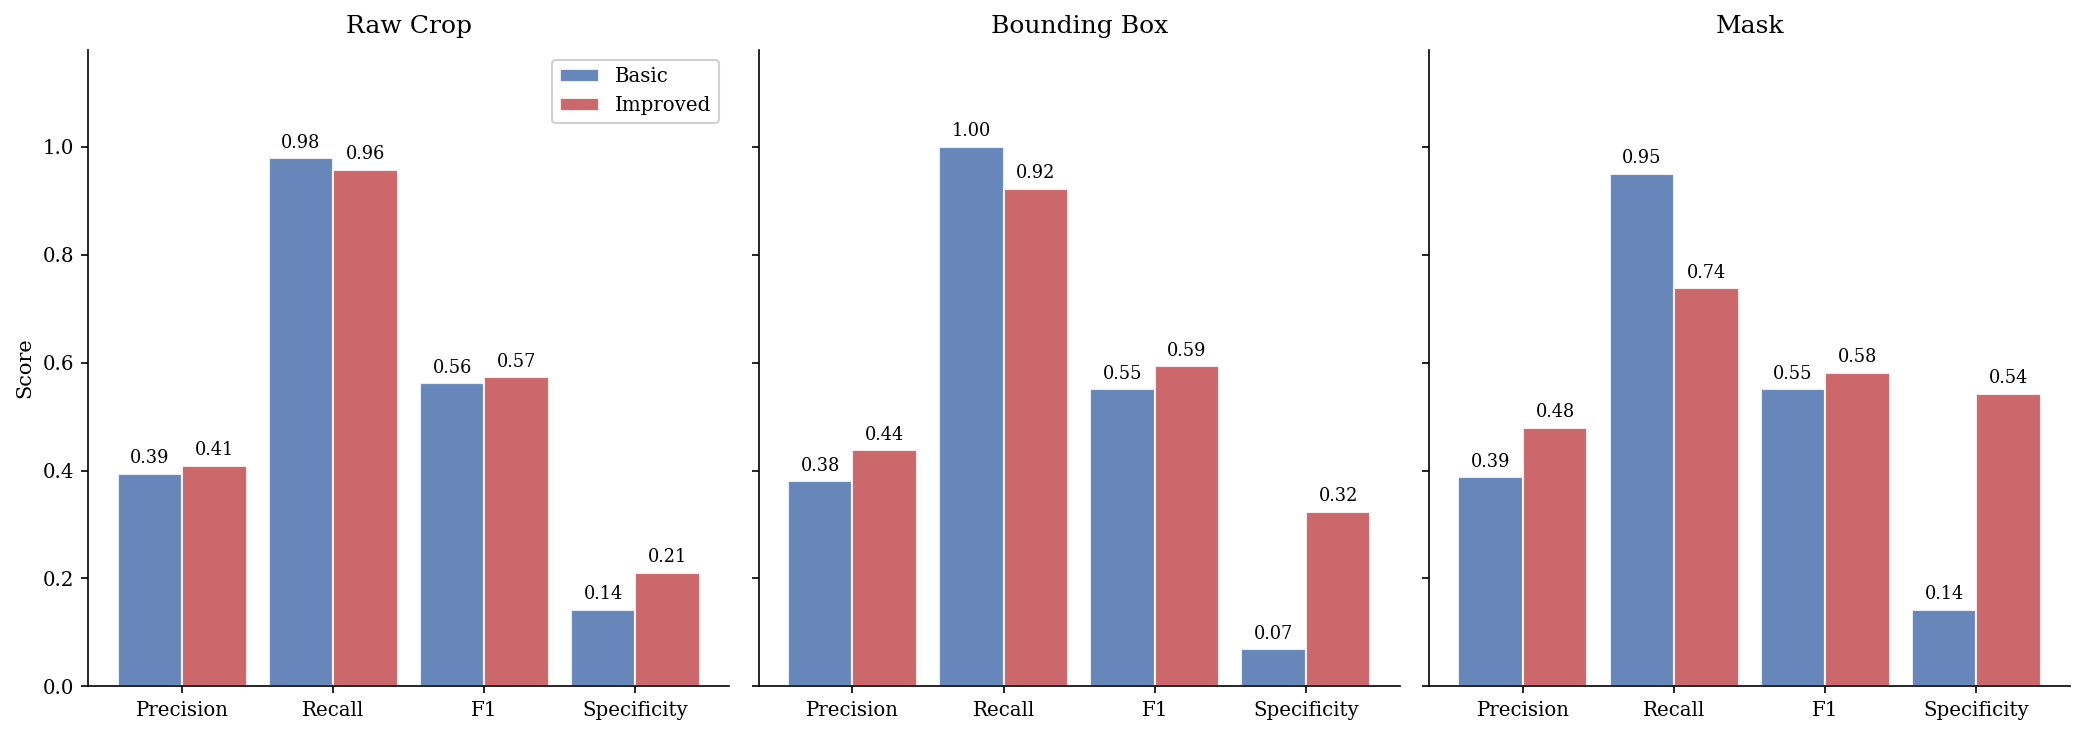

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── LOAD & CLEAN ──────────────────────────────────────────────────────────────
df1 = pd.read_csv("results_1.csv")           # basic prompts
df2 = pd.read_csv("results_2_cleaned.csv")   # improved prompts

def normalize_yn(val):
    return val.strip().lower().rstrip(".,;").strip()

df1["yn"] = df1["yes_no"].apply(normalize_yn)
df2["yn"] = df2["yes_no"].apply(normalize_yn)

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
CONDITIONS  = ["raw", "bbox", "mask"]
COND_LABEL  = {"raw": "Raw Crop", "bbox": "Bounding Box", "mask": "Mask"}
COLORS      = {"basic": "#4C72B0", "improved": "#C44E52"}

plt.rcParams.update({
    "font.family":       "serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
    "legend.fontsize":   9.5,
    "figure.dpi":        150,
})

# ── HELPER ────────────────────────────────────────────────────────────────────
def compute_metrics(df, condition):
    sub         = df[df["folder_type"] == condition]
    y_true      = (sub["subfolder"] == "mitotic").astype(int)
    y_pred      = (sub["yn"] == "yes").astype(int)
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1          = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return {"Precision": precision, "Recall": recall, "F1": f1, "Specificity": specificity}

metric_names     = ["Precision", "Recall", "F1", "Specificity"]
metrics_basic    = {c: compute_metrics(df1, c) for c in CONDITIONS}
metrics_improved = {c: compute_metrics(df2, c) for c in CONDITIONS}

# ── FIGURE 5 ──────────────────────────────────────────────────────────────────
bar_w   = 0.32                                        # wide enough to read clearly
spacing = 0.75                                        # tighter than default 1.0
x_pos   = np.arange(len(metric_names)) * spacing     # compress group spacing

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, condition in zip(axes, CONDITIONS):
    basic_vals    = [metrics_basic[condition][m]    for m in metric_names]
    improved_vals = [metrics_improved[condition][m] for m in metric_names]

    b1 = ax.bar(x_pos - bar_w/2, basic_vals,    bar_w,
                label="Basic",    color=COLORS["basic"],    alpha=0.85, edgecolor="white")
    b2 = ax.bar(x_pos + bar_w/2, improved_vals, bar_w,
                label="Improved", color=COLORS["improved"], alpha=0.85, edgecolor="white")

    # Value labels on top of every bar
    for bar, v in zip(list(b1) + list(b2), basic_vals + improved_vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8.5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(metric_names, rotation=0, ha="center")  # no rotation needed now
    ax.set_title(COND_LABEL[condition], fontsize=12, pad=8)
    ax.set_ylim(0, 1.18)

    if condition == "raw":
        ax.set_ylabel("Score")
        ax.legend(loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.savefig("figure5_basic_vs_improved_metrics.png", bbox_inches="tight")
plt.show()

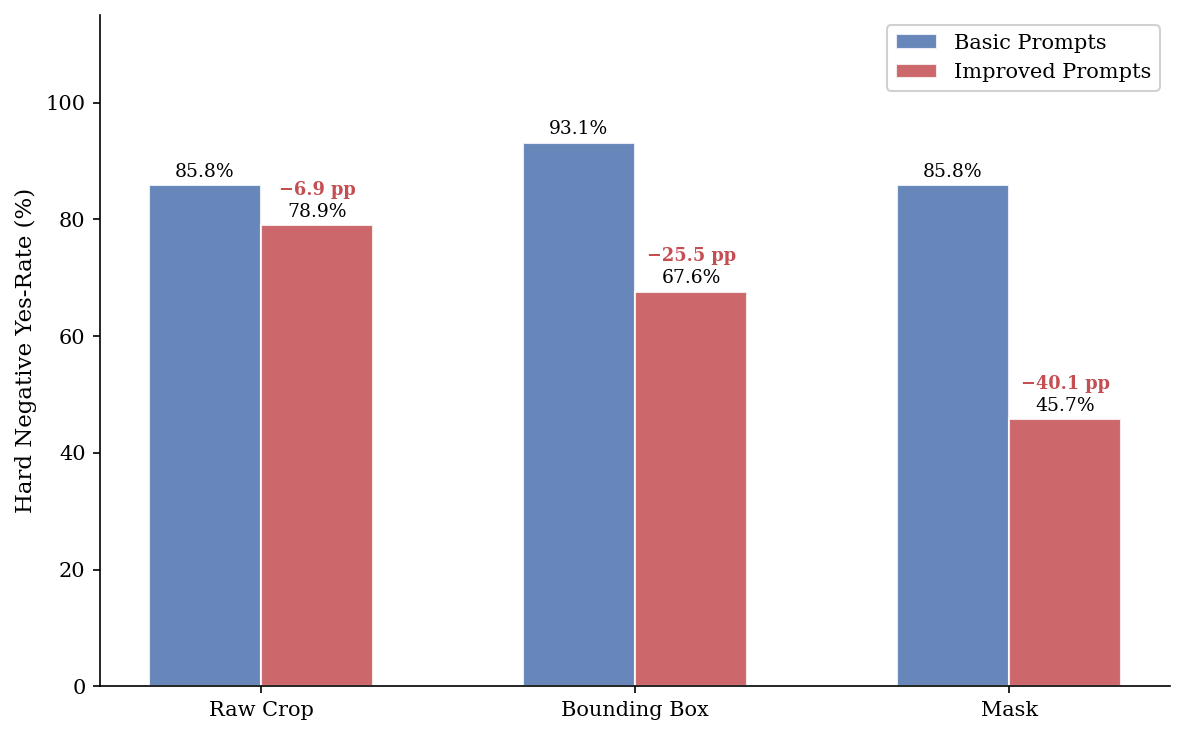

In [23]:
hn_basic    = [hn_yes_rate(df1, c) for c in CONDITIONS]
hn_improved = [hn_yes_rate(df2, c) for c in CONDITIONS]
changes     = [b - i for b, i in zip(hn_basic, hn_improved)]

x     = np.arange(len(CONDITIONS))
width = 0.30

fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - width / 2, [v * 100 for v in hn_basic],    width,
            label="Basic Prompts",    color=COLORS["basic"],    alpha=0.85, edgecolor="white")
b2 = ax.bar(x + width / 2, [v * 100 for v in hn_improved], width,
            label="Improved Prompts", color=COLORS["improved"], alpha=0.85, edgecolor="white")

# Value labels on bars
for bar, v in zip(b1, hn_basic):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9)

# Value labels + reduction annotations on improved bars
for bar, v, chg in zip(b2, hn_improved, changes):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{v*100:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4.5,
            f"−{chg*100:.1f} pp", ha="center", va="bottom",
            fontsize=8.5, color=COLORS["improved"], fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([COND_LABEL[c] for c in CONDITIONS])
ax.set_ylabel("Hard Negative Yes-Rate (%)")
ax.set_ylim(0, 115)

ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig("figure6_hn_yes_rate.png", bbox_inches="tight")
plt.show()

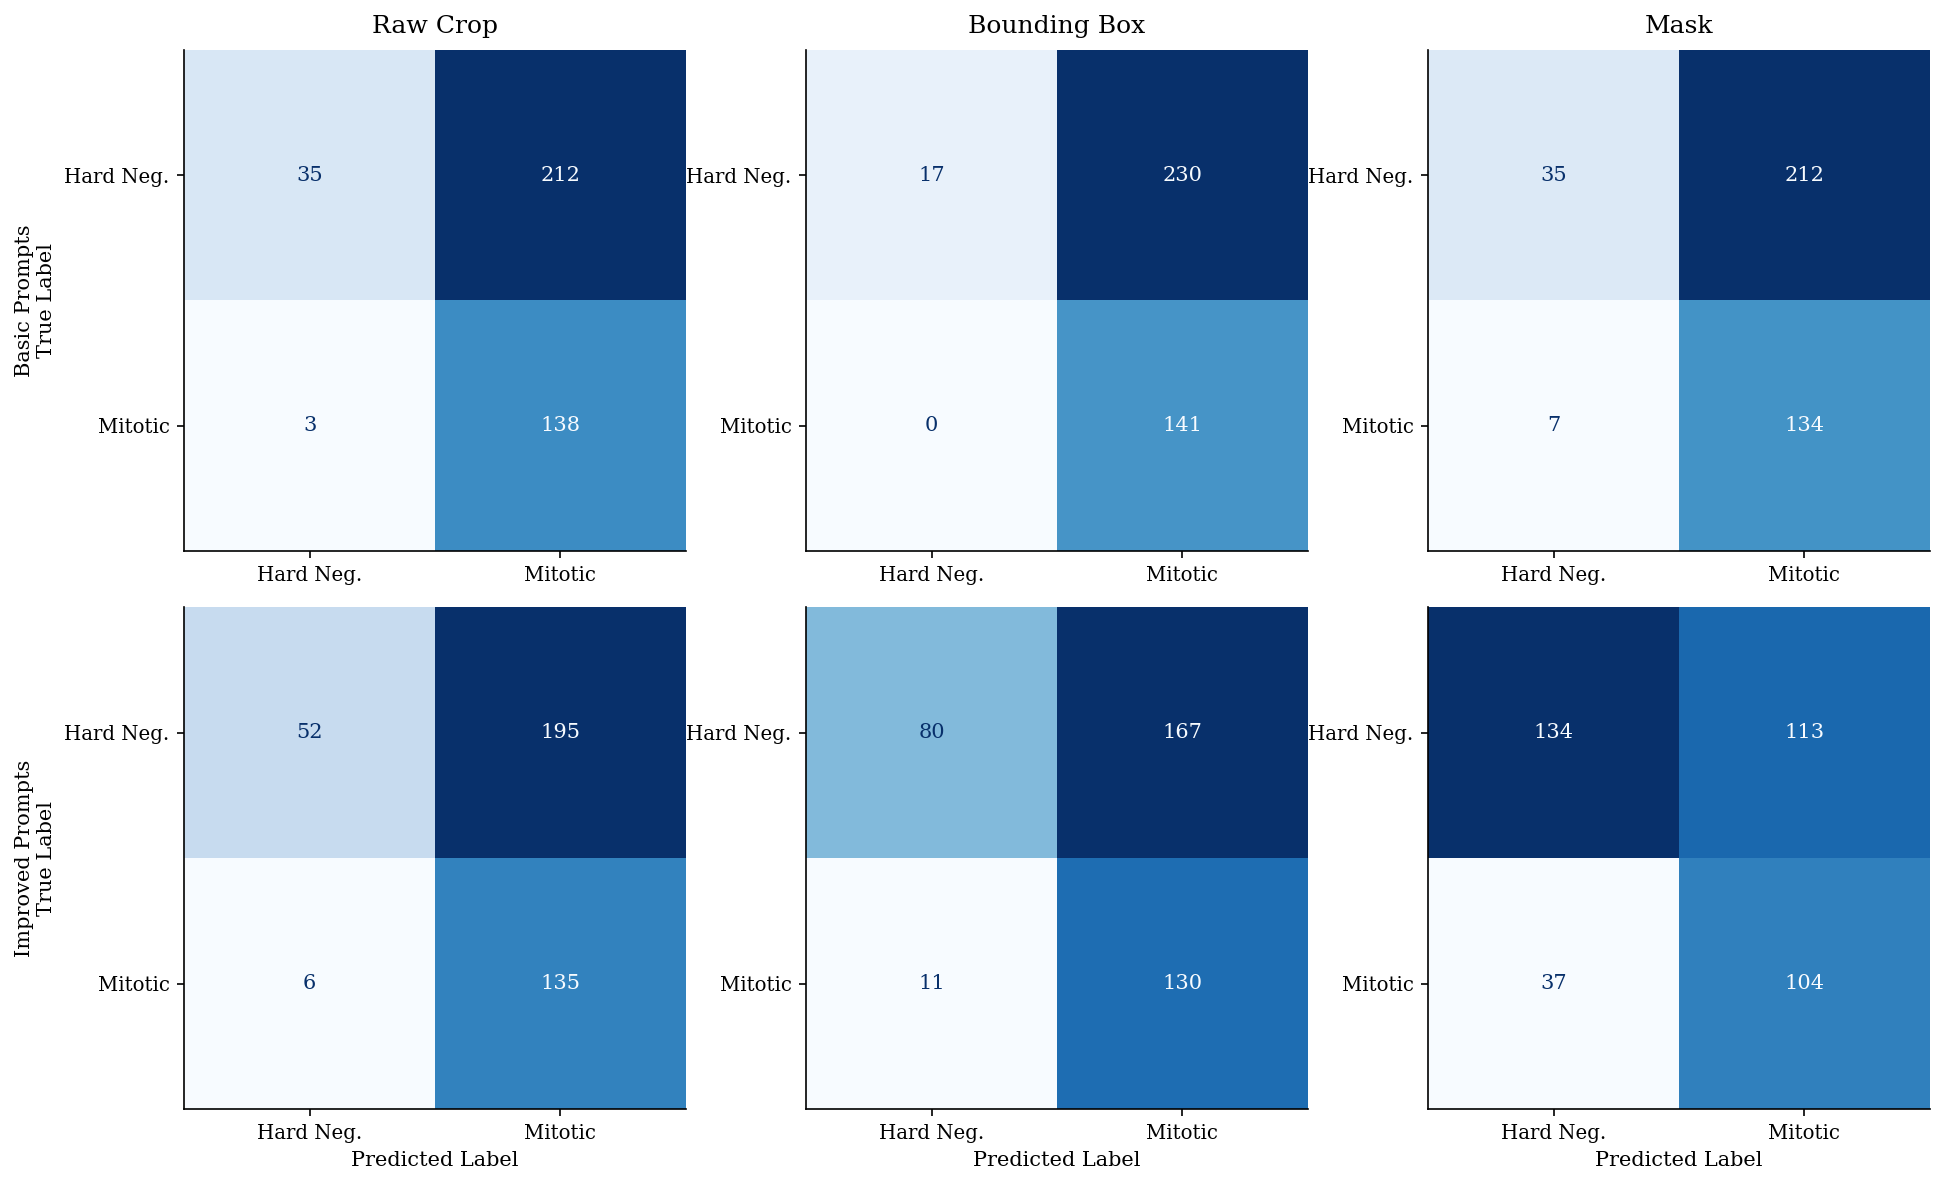

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for row_idx, (df, row_label) in enumerate(
    [(df1, "Basic Prompts"), (df2, "Improved Prompts")]
):
    for col_idx, condition in enumerate(CONDITIONS):
        ax     = axes[row_idx][col_idx]
        sub    = df[df["folder_type"] == condition]
        y_true = (sub["subfolder"] == "mitotic").astype(int)
        y_pred = (sub["yn"] == "yes").astype(int)
        cm     = confusion_matrix(y_true, y_pred)
        disp   = ConfusionMatrixDisplay(cm, display_labels=["Hard Neg.", "Mitotic"])
        disp.plot(ax=ax, cmap="Blues", colorbar=False)

        # Column headers on top row only
        if row_idx == 0:
            ax.set_title(COND_LABEL[condition], fontsize=12, pad=8)

        # Row labels on leftmost column only
        if col_idx == 0:
            ax.set_ylabel(f"{row_label}\nTrue Label")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Predicted Label" if row_idx == 1 else "")

plt.tight_layout()
plt.savefig("figure7_cm_basic_vs_improved.png", bbox_inches="tight")
plt.show()

In [6]:
!pip install statsmodels

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

# ── LOAD & CLEAN ──────────────────────────────────────────────────────────────
df1 = pd.read_csv("results_1.csv")
df2 = pd.read_csv("results_2_cleaned.csv")

def normalize_yn(val):
    return val.strip().lower().rstrip(".,;").strip()

df1["yn"] = df1["yes_no"].apply(normalize_yn)
df2["yn"] = df2["yes_no"].apply(normalize_yn)

def is_correct(row):
    return row["yn"] == "yes" if row["subfolder"] == "mitotic" else row["yn"] == "no"

df1["correct"] = df1.apply(is_correct, axis=1)
df2["correct"] = df2.apply(is_correct, axis=1)

CONDITIONS = ["raw", "bbox", "mask"]
COND_LABEL = {"raw": "Raw Crop", "bbox": "Bounding Box", "mask": "Mask"}

# ── MCNEMAR HELPER ────────────────────────────────────────────────────────────
def run_mcnemar(correct_a, correct_b):
    """
    Build 2x2 contingency table and run McNemar's test.
    Returns test statistic and p-value.
    """
    a_right_b_wrong = ((correct_a == True)  & (correct_b == False)).sum()
    a_wrong_b_right = ((correct_a == False) & (correct_b == True)).sum()
    # table format for statsmodels: [[both correct, a right b wrong],
    #                                [a wrong b right, both wrong]]
    both_right = ((correct_a == True)  & (correct_b == True)).sum()
    both_wrong = ((correct_a == False) & (correct_b == False)).sum()
    table = [[both_right, a_right_b_wrong],
             [a_wrong_b_right, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue

def pval_label(p):
    if p < 0.0001:
        return "p < 0.0001"
    elif p < 0.001:
        return "p < 0.001"
    elif p < 0.01:
        return "p < 0.01"
    elif p < 0.05:
        return f"p = {p:.3f}"
    else:
        return f"p = {p:.3f} (n.s.)"

plt.rcParams.update({
    "font.family":       "serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
    "figure.dpi":        150,
})

COLORS = {"basic": "#4C72B0", "improved": "#C44E52"}

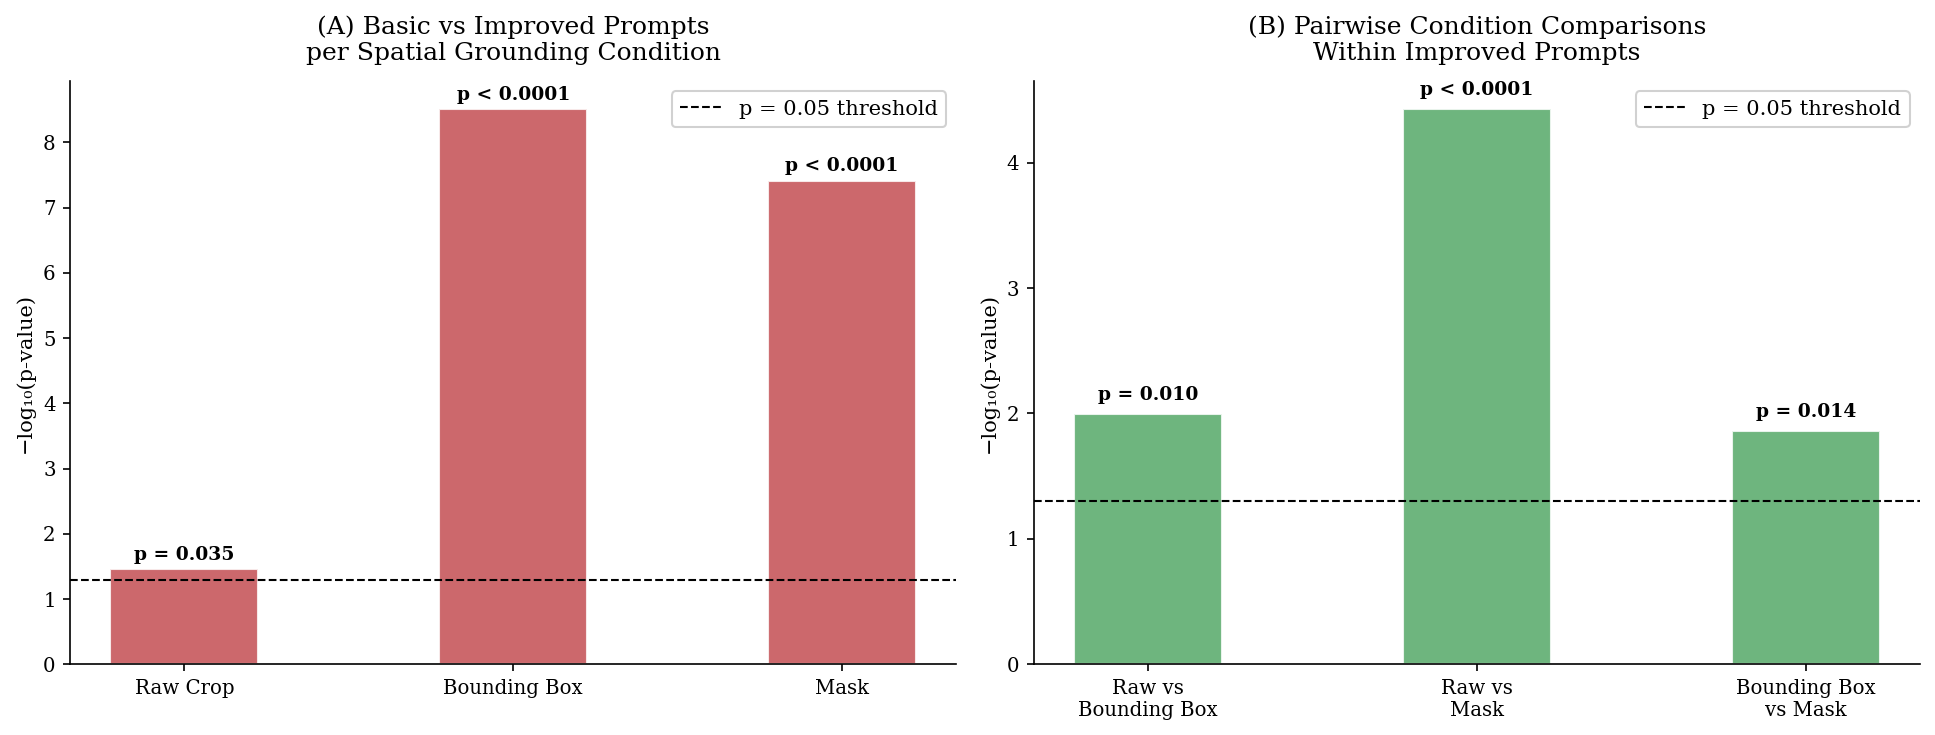

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

# ── LOAD & CLEAN ──────────────────────────────────────────────────────────────
df1 = pd.read_csv("results_1.csv")
df2 = pd.read_csv("results_2_cleaned.csv")

def normalize_yn(val):
    return val.strip().lower().rstrip(".,;").strip()

df1["yn"] = df1["yes_no"].apply(normalize_yn)
df2["yn"] = df2["yes_no"].apply(normalize_yn)

def is_correct(row):
    return row["yn"] == "yes" if row["subfolder"] == "mitotic" else row["yn"] == "no"

df1["correct"] = df1.apply(is_correct, axis=1)
df2["correct"] = df2.apply(is_correct, axis=1)

CONDITIONS  = ["raw", "bbox", "mask"]
COND_LABEL  = {"raw": "Raw Crop", "bbox": "Bounding Box", "mask": "Mask"}

plt.rcParams.update({
    "font.family":       "serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
    "figure.dpi":        150,
})

# ── HELPERS ───────────────────────────────────────────────────────────────────
def run_mcnemar(correct_a, correct_b):
    both_right      = ((correct_a == True)  & (correct_b == True)).sum()
    a_right_b_wrong = ((correct_a == True)  & (correct_b == False)).sum()
    a_wrong_b_right = ((correct_a == False) & (correct_b == True)).sum()
    both_wrong      = ((correct_a == False) & (correct_b == False)).sum()
    table  = [[both_right, a_right_b_wrong], [a_wrong_b_right, both_wrong]]
    result = mcnemar(table, exact=False, correction=True)
    return result.statistic, result.pvalue

def pval_label(p):
    if p < 0.0001:   return "p < 0.0001"
    elif p < 0.001:  return "p < 0.001"
    elif p < 0.01:   return "p < 0.01"
    elif p < 0.05:   return f"p = {p:.3f}"
    else:            return f"p = {p:.3f} (n.s.)"

# ── COMPUTE: basic vs improved per condition ──────────────────────────────────
pvals_bi = []
for condition in CONDITIONS:
    c1 = df1[df1["folder_type"] == condition]["correct"].reset_index(drop=True)
    c2 = df2[df2["folder_type"] == condition]["correct"].reset_index(drop=True)
    _, pval = run_mcnemar(c1, c2)
    pvals_bi.append(pval)

# ── COMPUTE: pairwise conditions within improved prompts ──────────────────────
pairs       = [("raw", "bbox"), ("raw", "mask"), ("bbox", "mask")]
pair_labels = ["Raw vs\nBounding Box", "Raw vs\nMask", "Bounding Box\nvs Mask"]
pvals_pw    = []
for cond_a, cond_b in pairs:
    c_a = df2[df2["folder_type"] == cond_a]["correct"].reset_index(drop=True)
    c_b = df2[df2["folder_type"] == cond_b]["correct"].reset_index(drop=True)
    _, pval = run_mcnemar(c_a, c_b)
    pvals_pw.append(pval)

# ── FIGURE 8: side by side ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── LEFT PANEL: basic vs improved ────────────────────────────────────────────
x1   = np.arange(len(CONDITIONS))
bars1 = ax1.bar(
    x1, [-np.log10(p) for p in pvals_bi],
    color="#C44E52", alpha=0.85, edgecolor="white", width=0.45
)
ax1.axhline(-np.log10(0.05), color="black", linewidth=1,
            linestyle="--", label="p = 0.05 threshold")
for bar, p in zip(bars1, pvals_bi):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.08,
             pval_label(p),
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_xticks(x1)
ax1.set_xticklabels([COND_LABEL[c] for c in CONDITIONS])
ax1.set_ylabel("−log₁₀(p-value)")
ax1.set_title("(A) Basic vs Improved Prompts\nper Spatial Grounding Condition", pad=10)
ax1.legend(framealpha=0.9)

# ── RIGHT PANEL: pairwise within improved ─────────────────────────────────────
x2    = np.arange(len(pairs))
bars2 = ax2.bar(
    x2, [-np.log10(p) for p in pvals_pw],
    color="#55A868", alpha=0.85, edgecolor="white", width=0.45
)
ax2.axhline(-np.log10(0.05), color="black", linewidth=1,
            linestyle="--", label="p = 0.05 threshold")
for bar, p in zip(bars2, pvals_pw):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.08,
             pval_label(p),
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_xticks(x2)
ax2.set_xticklabels(pair_labels)
ax2.set_ylabel("−log₁₀(p-value)")
ax2.set_title("(B) Pairwise Condition Comparisons\nWithin Improved Prompts", pad=10)
ax2.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig("figure8_mcnemar.png", bbox_inches="tight")
plt.show()